# Project 21 : Compairing two given random requences
    - Author: Jingjing XU  /  Student ID: 0180092002  / University of Luxembourg
    - Advisor: Prof. Raymond Bisdorff
    
    - Description: This project concerns the validation or not of the claim that two given random sequences, X1 and X2, each of length 10000 : see http://sma.uni.lu/bisdorff/CompStatDec18/project-21Data.csv have been obtained from the same RNG.
    
    - Tasks:
        1. Compare statistically and graphically the two given random sequences X1 and X2.
        2. Are the given sequences X1 and X2 potentially drawn from the same RNG ?
        3. Motivate your answer with arguments taken from the Computational Statistics Course.
        
    - Content:
        1. get data
        2. test
            2.1 chisq.test（chi-squared test）
            2.2 ks.test (Kolmogorov–Smirnov test)

# 1 - get data

In [193]:
mydata = read.csv("project-21Data.csv")

In [163]:
mydata #each of length 10000

X1,X2
<dbl>,<dbl>
0.564245,0.573220
0.482677,0.590576
0.535010,0.575761
0.483634,0.027552
0.698641,0.738864
0.463605,0.080347
0.273774,0.819277
0.813865,0.910975
0.166370,0.682505


# 2 - test

## Test if the given data is a uniform distribution. 
##  2.1 chisq.test（chi-squared test）

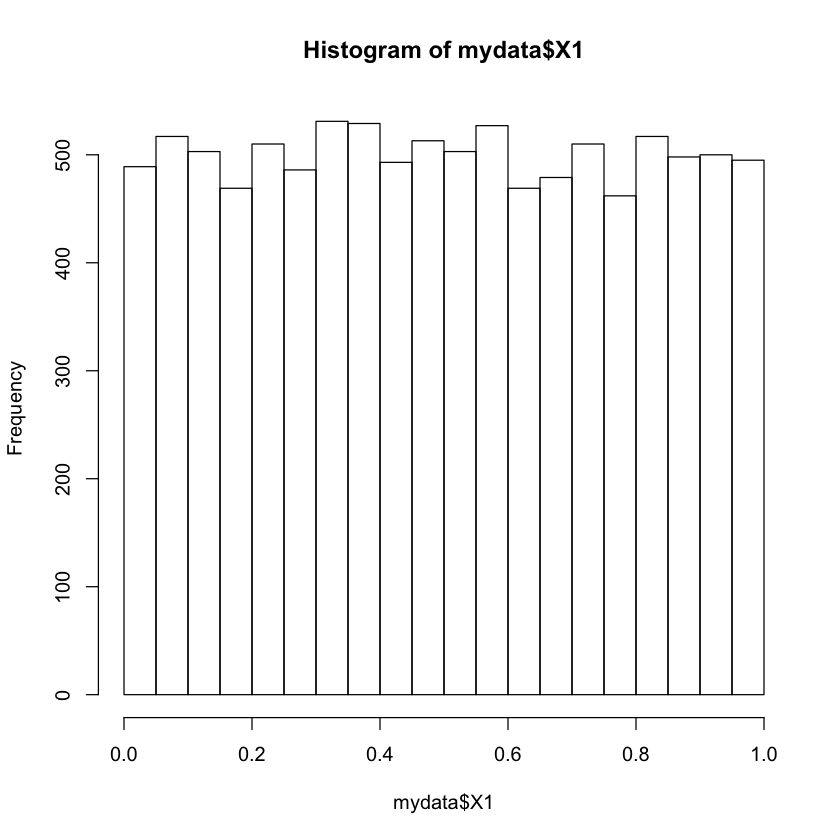

In [18]:
freq1 = hist(mydata$X1)

In [51]:
Ni1=freq1$counts

In [52]:
chisq.test(Ni1)


	Chi-squared test for given probabilities

data:  Ni1
X-squared = 15.396, df = 19, p-value = 0.6971


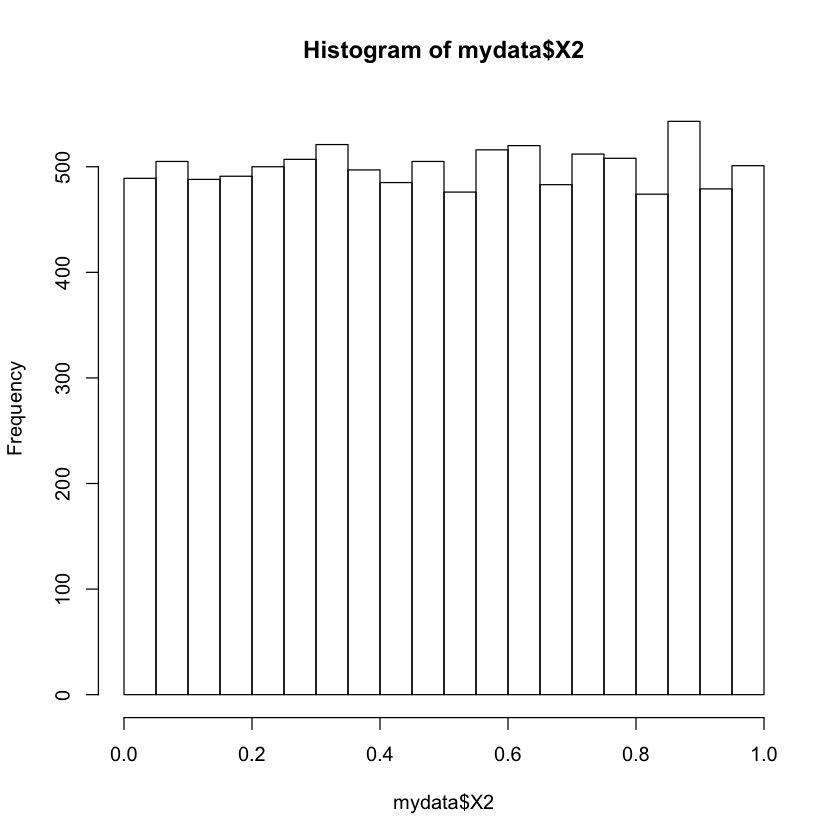

In [19]:
freq2 = hist(mydata$X2)

In [46]:
Ni2 = freq2$counts

In [63]:
chisq.test(Ni2)


	Chi-squared test for given probabilities

data:  Ni2
X-squared = 11.632, df = 19, p-value = 0.9007


In [134]:
rbind(Ni1, Ni2)

Ni1,489,517,503,469,510,486,531,529,493,513,503,527,469,479,510,462,517,498,500,495
Ni2,489,505,488,491,500,507,521,497,485,505,476,516,520,483,512,508,474,543,479,501


In [92]:
chisq.test(rbind(Ni1, Ni2))


	Pearson's Chi-squared test

data:  rbind(Ni1, Ni2)
X-squared = 12.627, df = 19, p-value = 0.8571


### - Conclusion 1: [Null hypothesis]: both samples come from the same distribution. [Result]: not rejected (p-value = 0.8571) since they do come from the exact same distribution.

##  2.2 ks.test (Kolmogorov–Smirnov test)

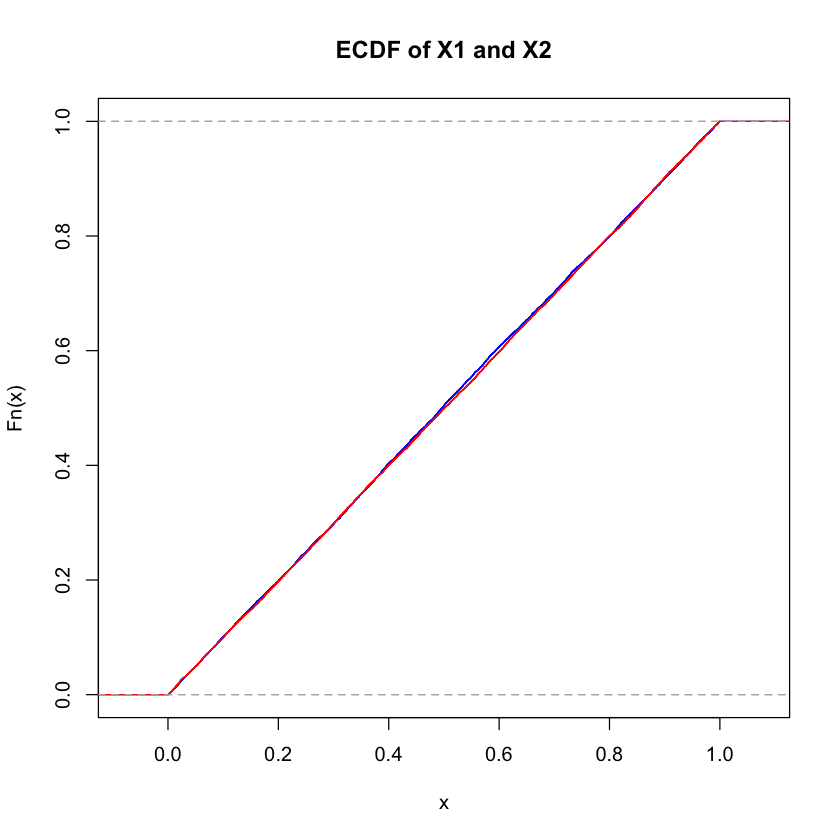

In [104]:
plot(ecdf(mydata$X1),col="blue", main = "ECDF of X1 and X2")
plot(ecdf(mydata$X2),add=T,col="red")

### - Conclusion 2: According to Cumulative Distribution Function showed above, the function is Uniform distribution (continuous)  unif(0,1)

In [57]:
ks.test(mydata$X1,mydata$X2)

Warning message in ks.test(mydata$X1, mydata$X2):
“p-value will be approximate in the presence of ties”



	Two-sample Kolmogorov-Smirnov test

data:  mydata$X1 and mydata$X2
D = 0.0099, p-value = 0.7112
alternative hypothesis: two-sided


### - Conclusion 3: “p-value will be approximate in the presence of ties”. The warning message is due to the implementation of the KS test in R, which expects a continuous distribution and thus there should not be any identical values in the two datasets i.e. ties. I’ve read several sources and they all mention that the KS test can deal with both discrete and continuous data (I’m guessing because it mainly deals with cumulative quantiles) but I’m not sure about the implementation in R. For more information[1], see this page http://www.physics.csbsju.edu/stats/KS-test.html.

## 2.3 Empirical Tests

### 2.3.1 gap Tests

In [190]:
library(randtoolbox)
library(rngWELL)

In [192]:
gap.test(mydata$X1,0,0.5,echo = TRUE)

ERROR: Error in gap.test(mydata$X1, 0, 0.5, echo = TRUE): unused argument (echo = TRUE)


In [189]:
serial.test(mydata$X1)


			 Serial test

chisq stat = 44, df = 63, p-value = 0.97

		 (sample size : 10000)

	observed number	 87 67 87 79 79 82 75 84 77 63 84 89 82 79 69 91 75 79 82 80 82 86 62 71 68 78 82 82 84 81 87 77 82 78 94 64 81 69 83 82 71 68 79 81 78 68 68 76 89 75 78 83 72 85 71 69 72 85 63 88 79 80 82 77 
	expected number	 78 


# Reference:
    [1] http://www.physics.csbsju.edu/stats/KS-test.html
    [2] https://davetang.org/muse/2012/04/17/comparing-different-distributions/